# Notebook 03: Constant baseline, Logistic Regression, XGBoost and LightGBM

**Objective:** Build the classical model ladder on the locked feature set. Train on dev (2019 to 2021), select on val (2022). Holdout rows are never loaded in this notebook.

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

targets = ["adverse_outcome", "readmission_30d"]

# holdout rows are filtered out at read time, so they never enter memory
mr = pd.read_parquet("../data/interim/model_ready.parquet",
                     filters=[("split", "!=", "holdout")])

feat_tbl = pd.read_csv("../reports/tables/feature_summary.csv")
features = feat_tbl["feature"].tolist()
cat_features = feat_tbl.loc[feat_tbl["kind"] == "categorical", "feature"].tolist()

missing = [c for c in features if c not in mr.columns]
assert not missing, missing
assert not {"arrival_day", "arrival_month", "arrival_day_of_week", "arrival_year"} & set(features)

dev = mr[mr["split"] == "dev"].reset_index(drop=True)
val = mr[mr["split"] == "val"].reset_index(drop=True)
del mr

print("features:", len(features), "| categorical:", cat_features)
print("dev:", dev.shape, "years", sorted(dev["arrival_year"].unique()))
print("val:", val.shape, "years", sorted(val["arrival_year"].unique()))
print("splits present:", sorted(set(dev["split"]) | set(val["split"])))
print()
print("target nulls dev/val:", int(dev[targets].isna().sum().sum()), "/", int(val[targets].isna().sum().sum()))
print(pd.DataFrame({"dev": dev[targets].mean(), "val": val[targets].mean()}).round(4))

features: 90 | categorical: ['city', 'urban_rural', 'hospital_type', 'gender', 'insurance_type', 'arrival_mode', 'chief_complaint']
dev: (400365, 105) years [np.int64(2019), np.int64(2020), np.int64(2021)]
val: (133853, 105) years [np.int64(2022)]
splits present: ['dev', 'val']

target nulls dev/val: 0 / 0
                    dev    val
adverse_outcome  0.4093  0.408
readmission_30d  0.1377  0.136


In [13]:
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             precision_score, recall_score, f1_score)

K_LIST = [0.01, 0.05, 0.10, 0.20]
rng = np.random.default_rng(42)

def ece_score(y, p, n_bins=10):
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)
    total = 0.0
    for b in range(n_bins):
        m = bins == b
        if m.any():
            total += m.mean() * abs(p[m].mean() - y[m].mean())
    return total

def at_k(y, score, k):
    n = int(round(len(y) * k))
    jitter = rng.random(len(score)) * 1e-9          # random tie-break
    top = np.argsort(-(score + jitter))[:n]
    hits = y[top].sum()
    return hits / y.sum(), hits / n                  # recall@K, precision@K

results = []

def evaluate(model, target, y, p, split="val", thr=0.5, note=""):
    y, p = np.asarray(y), np.asarray(p)
    row = {"model": model, "target": target, "split": split, "note": note,
           "pr_auc": average_precision_score(y, p),
           "roc_auc": roc_auc_score(y, p),
           "brier": brier_score_loss(y, p),
           "ece": ece_score(y, p),
           "precision@thr": precision_score(y, p >= thr, zero_division=0),
           "recall@thr": recall_score(y, p >= thr, zero_division=0),
           "f1@thr": f1_score(y, p >= thr, zero_division=0)}
    for k in K_LIST:
        r, pr = at_k(y, p, k)
        row[f"recall@{int(k*100)}%"] = r
        row[f"precision@{int(k*100)}%"] = pr
    results.append(row)
    return row

# constant baseline: predict the dev prevalence for every val row
for t in targets:
    p0 = dev[t].mean()
    evaluate("constant_prevalence", t, val[t].values, np.full(len(val), p0), thr=p0)

show = pd.DataFrame(results).set_index(["model", "target"]).drop(columns=["split", "note"])
print(show.round(4).T.to_string())

model         constant_prevalence                
target            adverse_outcome readmission_30d
pr_auc                     0.4080          0.1360
roc_auc                    0.5000          0.5000
brier                      0.2415          0.1175
ece                        0.0012          0.0016
precision@thr              0.4080          0.1360
recall@thr                 1.0000          1.0000
f1@thr                     0.5796          0.2395
recall@1%                  0.0094          0.0107
precision@1%               0.3846          0.1449
recall@5%                  0.0510          0.0495
precision@5%               0.4161          0.1348
recall@10%                 0.1007          0.1018
precision@10%              0.4108          0.1385
recall@20%                 0.1988          0.1990
precision@20%              0.4056          0.1354


In [14]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

binary_features  = feat_tbl.loc[feat_tbl["kind"] == "binary", "feature"].tolist()
numeric_features = feat_tbl.loc[feat_tbl["kind"] == "numeric", "feature"].tolist()
print(len(numeric_features), "numeric |", len(binary_features), "binary |", len(cat_features), "categorical")

def make_lr(C, class_weight="balanced"):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), numeric_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])
    return Pipeline([("pre", pre),
                     ("lr", LogisticRegression(C=C, class_weight=class_weight, max_iter=300))])

preds = {}   # (model, target) -> val probabilities
grid = []

for t in targets:
    best = None
    for C in [0.01, 0.1, 1.0]:
        t0 = time.time()
        m = make_lr(C).fit(dev[features], dev[t])
        p = m.predict_proba(val[features])[:, 1]
        secs = round(time.time() - t0)
        pr = average_precision_score(val[t], p)
        grid.append((t, C, round(pr, 4), round(roc_auc_score(val[t], p), 4), secs))
        if best is None or pr > best[0]:
            best = (pr, C, p)
    preds[("logreg_plain", t)] = best[2]
    evaluate("logreg_plain", t, val[t].values, best[2], note=f"C={best[1]}, balanced, median impute, no indicators")

print(pd.DataFrame(grid, columns=["target", "C", "val_pr_auc", "val_roc_auc", "fit_seconds"]).to_string(index=False))
print()
cols = ["pr_auc", "roc_auc", "recall@5%", "precision@5%", "recall@10%", "precision@10%", "brier", "ece"]
r = pd.DataFrame(results)
print(r[r["model"] == "logreg_plain"].set_index("target")[cols + ["note"]].round(4).to_string())

53 numeric | 30 binary | 7 categorical
         target    C  val_pr_auc  val_roc_auc  fit_seconds
adverse_outcome 0.01      0.7443       0.7964            8
adverse_outcome 0.10      0.7443       0.7966            8
adverse_outcome 1.00      0.7443       0.7966            8
readmission_30d 0.01      0.2080       0.6068            8
readmission_30d 0.10      0.2073       0.6072            8
readmission_30d 1.00      0.2070       0.6073            8

                 pr_auc  roc_auc  recall@5%  precision@5%  recall@10%  precision@10%   brier     ece                                            note
target                                                                                                                                              
adverse_outcome  0.7443   0.7966     0.1139        0.9298      0.2174         0.8873  0.1828  0.0680   C=0.1, balanced, median impute, no indicators
readmission_30d  0.2080   0.6068     0.1119        0.3043      0.1987         0.2703  0.2393  0.3501

In [15]:
from sklearn.preprocessing import SplineTransformer

def make_lr_age(C, class_weight="balanced"):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), numeric_features),
        ("age_spline", SplineTransformer(n_knots=8, degree=3, knots="quantile",
                                         include_bias=False), ["age"]),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])
    return Pipeline([("pre", pre),
                     ("lr", LogisticRegression(C=C, class_weight=class_weight, max_iter=300))])

grid2 = []
for t in targets:
    best = None
    for C in [0.01, 0.1, 1.0]:
        m = make_lr_age(C).fit(dev[features], dev[t])
        p = m.predict_proba(val[features])[:, 1]
        pr = average_precision_score(val[t], p)
        grid2.append((t, C, round(pr, 4), round(roc_auc_score(val[t], p), 4)))
        if best is None or pr > best[0]:
            best = (pr, C, p)
    preds[("logreg_age_spline", t)] = best[2]
    evaluate("logreg_age_spline", t, val[t].values, best[2],
             note=f"C={best[1]}, balanced, median impute, age spline (8 knots)")

print(pd.DataFrame(grid2, columns=["target", "C", "val_pr_auc", "val_roc_auc"]).to_string(index=False))
print()
r = pd.DataFrame(results)
cols = ["pr_auc", "roc_auc", "recall@5%", "precision@5%", "recall@10%", "precision@10%"]
print(r[r["model"].isin(["logreg_plain", "logreg_age_spline"])]
      .set_index(["target", "model"])[cols].round(4).sort_index().to_string())

         target    C  val_pr_auc  val_roc_auc
adverse_outcome 0.01      0.7463       0.7977
adverse_outcome 0.10      0.7463       0.7977
adverse_outcome 1.00      0.7463       0.7977
readmission_30d 0.01      0.2147       0.6085
readmission_30d 0.10      0.2148       0.6086
readmission_30d 1.00      0.2148       0.6086

                                   pr_auc  roc_auc  recall@5%  precision@5%  recall@10%  precision@10%
target          model                                                                                 
adverse_outcome logreg_age_spline  0.7463   0.7977     0.1145        0.9340      0.2180         0.8894
                logreg_plain       0.7443   0.7966     0.1139        0.9298      0.2174         0.8873
readmission_30d logreg_age_spline  0.2148   0.6086     0.1144        0.3112      0.2007         0.2731
                logreg_plain       0.2080   0.6068     0.1119        0.3043      0.1987         0.2703


In [16]:
lab7 = ["troponin_i_ngml", "bnp_pgl", "d_dimer_mgfl", "lactate_mmoll",
        "lipase_ul", "procalcitonin_ngl", "albumin_gdl"]
ind_cols = [f"{c}_missing" for c in lab7]
for d in (dev, val):
    for c in lab7:
        d[f"{c}_missing"] = d[c].isna().astype(int)

def make_lr_ind(C, class_weight="balanced"):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), numeric_features),
        ("age_spline", SplineTransformer(n_knots=8, degree=3, knots="quantile",
                                         include_bias=False), ["age"]),
        ("bin", "passthrough", binary_features + ind_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])
    return Pipeline([("pre", pre),
                     ("lr", LogisticRegression(C=C, class_weight=class_weight, max_iter=300))])

grid3 = []
for t in targets:
    best = None
    for C in [0.01, 0.1, 1.0]:
        m = make_lr_ind(C).fit(dev[features + ind_cols], dev[t])
        p = m.predict_proba(val[features + ind_cols])[:, 1]
        pr = average_precision_score(val[t], p)
        grid3.append((t, C, round(pr, 4), round(roc_auc_score(val[t], p), 4)))
        if best is None or pr > best[0]:
            best = (pr, C, p)
    preds[("logreg_age_spline_ind", t)] = best[2]
    evaluate("logreg_age_spline_ind", t, val[t].values, best[2],
             note=f"C={best[1]}, balanced, age spline, +7 lab missing indicators")

print(pd.DataFrame(grid3, columns=["target", "C", "val_pr_auc", "val_roc_auc"]).to_string(index=False))
print()

def paired_boot(y, p_a, p_b, n=200, seed=0):
    rs = np.random.default_rng(seed)
    y, p_a, p_b = np.asarray(y), np.asarray(p_a), np.asarray(p_b)
    diffs = []
    for _ in range(n):
        i = rs.integers(0, len(y), len(y))
        diffs.append(average_precision_score(y[i], p_b[i]) - average_precision_score(y[i], p_a[i]))
    return np.percentile(diffs, [2.5, 50, 97.5]).round(4)

for t in targets:
    print(t)
    print("  spline minus plain       [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("logreg_plain", t)], preds[("logreg_age_spline", t)]))
    print("  indicators minus spline  [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("logreg_age_spline", t)], preds[("logreg_age_spline_ind", t)]))

         target    C  val_pr_auc  val_roc_auc
adverse_outcome 0.01      0.7462       0.7977
adverse_outcome 0.10      0.7463       0.7977
adverse_outcome 1.00      0.7463       0.7977
readmission_30d 0.01      0.2147       0.6085
readmission_30d 0.10      0.2147       0.6086
readmission_30d 1.00      0.2147       0.6086

adverse_outcome
  spline minus plain       [2.5%, median, 97.5%]: [0.0017 0.002  0.0024]
  indicators minus spline  [2.5%, median, 97.5%]: [-0.0001 -0.      0.    ]
readmission_30d
  spline minus plain       [2.5%, median, 97.5%]: [0.0049 0.0067 0.0088]
  indicators minus spline  [2.5%, median, 97.5%]: [-0.0002 -0.0001  0.0001]


In [17]:
%pip install xgboost
import xgboost as xgb
print("xgboost", xgb.__version__)

def to_cat(d):
    X = d[features].copy()
    for c in cat_features:
        X[c] = X[c].astype(pd.CategoricalDtype(sorted(dev[c].unique())))
    return X

Xdev, Xval = to_cat(dev), to_cat(val)
print("Unseen val categories:", {c: int(Xval[c].isna().sum()) for c in cat_features if Xval[c].isna().any()})

for t in targets:
    t0 = time.time()
    m = xgb.XGBClassifier(
        n_estimators=2000, learning_rate=0.05, max_depth=6, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.8, tree_method="hist",
        enable_categorical=True, eval_metric="aucpr", early_stopping_rounds=50,
        n_jobs=-1, random_state=42)
    m.fit(Xdev, dev[t], eval_set=[(Xval, val[t])], verbose=False)
    p = m.predict_proba(Xval)[:, 1]
    preds[("xgboost", t)] = p
    evaluate("xgboost", t, val[t].values, p, thr=dev[t].mean(),
             note=f"native NaN, unweighted, {m.best_iteration + 1} trees, early stop on val")
    print(t, "| trees:", m.best_iteration + 1, "| seconds:", round(time.time() - t0))

r = pd.DataFrame(results)
cols = ["pr_auc", "roc_auc", "recall@5%", "precision@5%", "recall@10%", "precision@10%"]
print()
print(r[r["model"].isin(["logreg_age_spline", "xgboost"])]
      .set_index(["target", "model"])[cols].round(4).sort_index().to_string())
print()
for t in targets:
    print(t, "xgboost minus logreg_age_spline [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("logreg_age_spline", t)], preds[("xgboost", t)]))

Note: you may need to restart the kernel to use updated packages.
xgboost 3.4.1
Unseen val categories: {}
adverse_outcome | trees: 185 | seconds: 25
readmission_30d | trees: 36 | seconds: 10

                                   pr_auc  roc_auc  recall@5%  precision@5%  recall@10%  precision@10%
target          model                                                                                 
adverse_outcome logreg_age_spline  0.7463   0.7977     0.1145        0.9340      0.2180         0.8894
                xgboost            0.7548   0.8039     0.1154        0.9416      0.2207         0.9007
readmission_30d logreg_age_spline  0.2148   0.6086     0.1144        0.3112      0.2007         0.2731
                xgboost            0.2138   0.6080     0.1136        0.3091      0.2012         0.2737

adverse_outcome xgboost minus logreg_age_spline [2.5%, median, 97.5%]: [0.0074 0.0085 0.0096]
readmission_30d xgboost minus logreg_age_spline [2.5%, median, 97.5%]: [-0.0025 -0.0009  0.0004

In [18]:
import lightgbm as lgb
print("lightgbm", lgb.__version__)

for t in targets:
    t0 = time.time()
    m = lgb.LGBMClassifier(
        n_estimators=2000, learning_rate=0.05, num_leaves=31, min_child_samples=20,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbose=-1)
    m.fit(Xdev, dev[t], eval_set=[(Xval, val[t])], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    p = m.predict_proba(Xval)[:, 1]
    preds[("lightgbm", t)] = p
    evaluate("lightgbm", t, val[t].values, p, thr=dev[t].mean(),
             note=f"native NaN, unweighted, {m.best_iteration_} trees, early stop on val")
    print(t, "| trees:", m.best_iteration_, "| seconds:", round(time.time() - t0))

r = pd.DataFrame(results)
cols = ["pr_auc", "roc_auc", "recall@5%", "precision@5%", "recall@10%", "precision@10%"]
print()
print(r[r["model"].isin(["logreg_age_spline", "xgboost", "lightgbm"])]
      .set_index(["target", "model"])[cols].round(4).sort_index().to_string())
print()
for t in targets:
    print(t)
    print("  lightgbm minus xgboost           [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("xgboost", t)], preds[("lightgbm", t)]))
    print("  lightgbm minus logreg_age_spline [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("logreg_age_spline", t)], preds[("lightgbm", t)]))

lightgbm 4.7.0
adverse_outcome | trees: 291 | seconds: 8
readmission_30d | trees: 51 | seconds: 3

                                   pr_auc  roc_auc  recall@5%  precision@5%  recall@10%  precision@10%
target          model                                                                                 
adverse_outcome lightgbm           0.7553   0.8041     0.1156        0.9432      0.2205         0.8997
                logreg_age_spline  0.7463   0.7977     0.1145        0.9340      0.2180         0.8894
                xgboost            0.7548   0.8039     0.1154        0.9416      0.2207         0.9007
readmission_30d lightgbm           0.2138   0.6080     0.1145        0.3115      0.2002         0.2723
                logreg_age_spline  0.2148   0.6086     0.1144        0.3112      0.2007         0.2731
                xgboost            0.2138   0.6080     0.1136        0.3091      0.2012         0.2737

adverse_outcome
  lightgbm minus xgboost           [2.5%, median, 97.5%]: [0

In [19]:
import warnings
warnings.filterwarnings("ignore", message=".*eval_set.*deprecated.*")

nan_cols = [c for c in features if dev[c].isna().any()]
print("Columns with NaN in dev:", nan_cols)
med = dev[nan_cols].median()

def impute(X):
    X = X.copy()
    X[nan_cols] = X[nan_cols].fillna(med)
    return X

def fit_lgb(Xtr, ytr, Xva, yva):
    m = lgb.LGBMClassifier(
        n_estimators=2000, learning_rate=0.05, num_leaves=31, min_child_samples=20,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbose=-1)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    return m.predict_proba(Xva)[:, 1], m.best_iteration_

variants = {
    "lightgbm_imputed": (impute(Xdev), impute(Xval), "median impute"),
    "lightgbm_imputed_ind": (pd.concat([impute(Xdev), dev[ind_cols]], axis=1),
                             pd.concat([impute(Xval), val[ind_cols]], axis=1),
                             "median impute + 7 lab indicators"),
}
for name, (Xa, Xb, label) in variants.items():
    for t in targets:
        p, n_trees = fit_lgb(Xa, dev[t], Xb, val[t])
        preds[(name, t)] = p
        evaluate(name, t, val[t].values, p, thr=dev[t].mean(),
                 note=f"{label}, unweighted, {n_trees} trees, early stop on val")
        print(name, t, "| trees:", n_trees)

r = pd.DataFrame(results)
cols = ["pr_auc", "roc_auc", "recall@5%", "precision@5%", "recall@10%", "precision@10%"]
print()
print(r[r["model"].str.startswith("lightgbm")].set_index(["target", "model"])[cols].round(4).sort_index().to_string())
print()
for t in targets:
    print(t)
    print("  imputed minus native          [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("lightgbm", t)], preds[("lightgbm_imputed", t)]))
    print("  imputed+ind minus imputed     [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("lightgbm_imputed", t)], preds[("lightgbm_imputed_ind", t)]))
    print("  imputed+ind minus native      [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("lightgbm", t)], preds[("lightgbm_imputed_ind", t)]))

Columns with NaN in dev: ['lactate_mmoll', 'troponin_i_ngml', 'bnp_pgl', 'procalcitonin_ngl', 'lipase_ul', 'd_dimer_mgfl', 'albumin_gdl', 'egfr_ml_min']
lightgbm_imputed adverse_outcome | trees: 275
lightgbm_imputed readmission_30d | trees: 41
lightgbm_imputed_ind adverse_outcome | trees: 225
lightgbm_imputed_ind readmission_30d | trees: 43

                                      pr_auc  roc_auc  recall@5%  precision@5%  recall@10%  precision@10%
target          model                                                                                    
adverse_outcome lightgbm              0.7553   0.8041     0.1156        0.9432      0.2205         0.8997
                lightgbm_imputed      0.7553   0.8041     0.1153        0.9411      0.2206         0.9003
                lightgbm_imputed_ind  0.7550   0.8040     0.1153        0.9408      0.2204         0.8994
readmission_30d lightgbm              0.2138   0.6080     0.1145        0.3115      0.2002         0.2723
                ligh

In [20]:
lab_group = feat_tbl.loc[feat_tbl["group"] == "laboratory", "feature"].tolist()
print("Lab-group columns removed:", len(lab_group), "| includes sofa_score_approx:", "sofa_score_approx" in lab_group)
no_lab = [c for c in features if c not in lab_group]
print("Features remaining:", len(no_lab))

num_nl = [c for c in numeric_features if c in no_lab]
bin_nl = [c for c in binary_features if c in no_lab]

def make_lr_nolab(C=0.1):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num_nl),
        ("age_spline", SplineTransformer(n_knots=8, degree=3, knots="quantile",
                                         include_bias=False), ["age"]),
        ("bin", "passthrough", bin_nl),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])
    return Pipeline([("pre", pre),
                     ("lr", LogisticRegression(C=C, class_weight="balanced", max_iter=300))])

for t in targets:
    m = make_lr_nolab().fit(dev[no_lab], dev[t])
    p = m.predict_proba(val[no_lab])[:, 1]
    preds[("logreg_age_spline_nolabs", t)] = p
    evaluate("logreg_age_spline_nolabs", t, val[t].values, p,
             note="C=0.1, balanced, age spline, no lab columns")

    p, n_trees = fit_lgb(Xdev[no_lab], dev[t], Xval[no_lab], val[t])
    preds[("lightgbm_nolabs", t)] = p
    evaluate("lightgbm_nolabs", t, val[t].values, p, thr=dev[t].mean(),
             note=f"native NaN, unweighted, no lab columns, {n_trees} trees, early stop on val")
    print(t, "| lightgbm trees:", n_trees)

r = pd.DataFrame(results)
cols = ["pr_auc", "roc_auc", "recall@5%", "precision@5%", "recall@10%", "precision@10%"]
keep = ["logreg_age_spline", "logreg_age_spline_nolabs", "lightgbm", "lightgbm_nolabs"]
print()
print(r[r["model"].isin(keep)].set_index(["target", "model"])[cols].round(4).sort_index().to_string())
print()
for t in targets:
    print(t, "(with labs minus without labs)")
    print("  logreg   [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("logreg_age_spline_nolabs", t)], preds[("logreg_age_spline", t)]))
    print("  lightgbm [2.5%, median, 97.5%]:",
          paired_boot(val[t], preds[("lightgbm_nolabs", t)], preds[("lightgbm", t)]))

Lab-group columns removed: 30 | includes sofa_score_approx: True
Features remaining: 60
adverse_outcome | lightgbm trees: 245
readmission_30d | lightgbm trees: 23

                                          pr_auc  roc_auc  recall@5%  precision@5%  recall@10%  precision@10%
target          model                                                                                        
adverse_outcome lightgbm                  0.7553   0.8041     0.1156        0.9432      0.2205         0.8997
                lightgbm_nolabs           0.7476   0.7976     0.1150        0.9380      0.2191         0.8940
                logreg_age_spline         0.7463   0.7977     0.1145        0.9340      0.2180         0.8894
                logreg_age_spline_nolabs  0.7403   0.7930     0.1144        0.9334      0.2162         0.8820
readmission_30d lightgbm                  0.2138   0.6080     0.1145        0.3115      0.2002         0.2723
                lightgbm_nolabs           0.2135   0.6079     0.11

         target               model  pr_auc  pr_auc_ci_low  pr_auc_ci_high  roc_auc
adverse_outcome constant_prevalence  0.4080         0.4058          0.4103   0.5000
adverse_outcome   logreg_age_spline  0.7463         0.7428          0.7496   0.7977
adverse_outcome             xgboost  0.7548         0.7516          0.7580   0.8039
adverse_outcome            lightgbm  0.7553         0.7519          0.7584   0.8041
readmission_30d constant_prevalence  0.1360         0.1343          0.1380   0.5000
readmission_30d   logreg_age_spline  0.2148         0.2100          0.2192   0.6086
readmission_30d             xgboost  0.2138         0.2093          0.2190   0.6080
readmission_30d            lightgbm  0.2138         0.2089          0.2187   0.6080


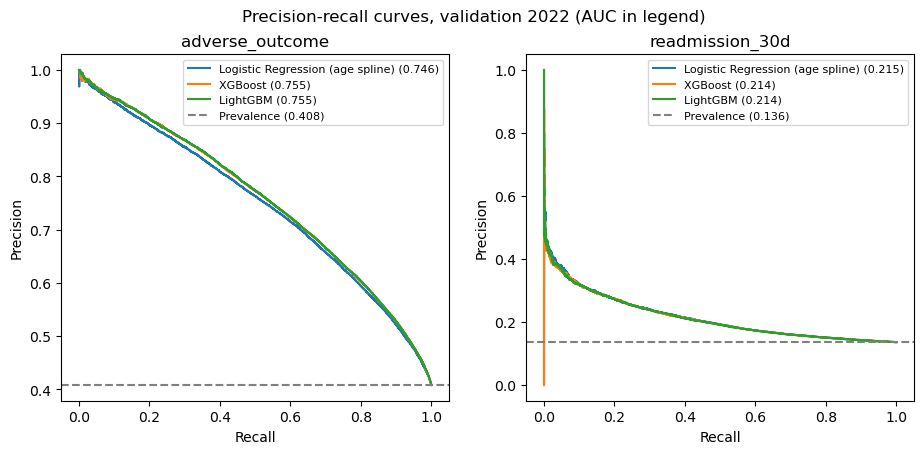

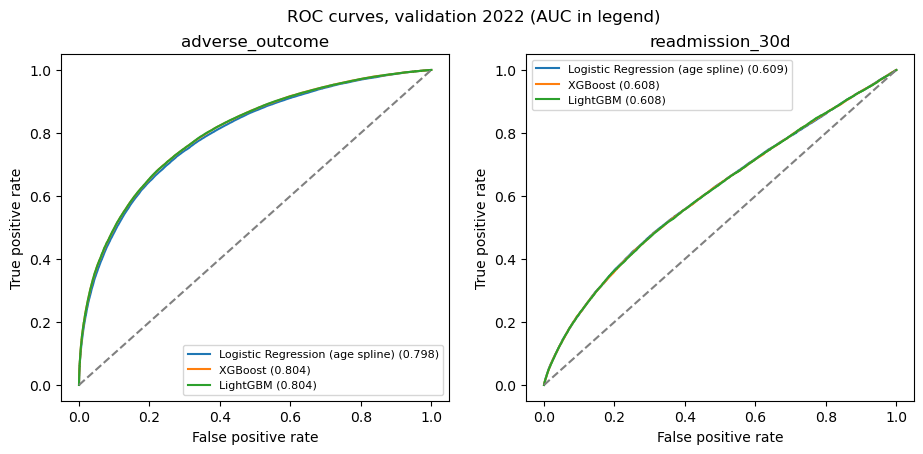

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

figs = Path("../reports/figures"); figs.mkdir(parents=True, exist_ok=True)
tables = Path("../reports/tables"); tables.mkdir(parents=True, exist_ok=True)

for t in targets:
    preds[("constant_prevalence", t)] = np.full(len(val), dev[t].mean())

r = pd.DataFrame(results).drop_duplicates(["model", "target"], keep="last")
rank_cols = [c for c in r.columns if c.endswith("%")]
keep_cols = ["model", "target", "pr_auc", "roc_auc", "brier", "ece"] + rank_cols

def boot_ci(y, p, n=200, seed=0):
    rs = np.random.default_rng(seed)
    y, p = np.asarray(y), np.asarray(p)
    vals = []
    for _ in range(n):
        i = rs.integers(0, len(y), len(y))
        vals.append(average_precision_score(y[i], p[i]))
    return np.percentile(vals, [2.5, 97.5])

main = ["constant_prevalence", "logreg_age_spline", "xgboost", "lightgbm"]
mc = r[r["model"].isin(main)][keep_cols].copy()
ci = [boot_ci(val[row.target], preds[(row.model, row.target)]) for row in mc.itertuples()]
mc["pr_auc_ci_low"] = [c[0] for c in ci]
mc["pr_auc_ci_high"] = [c[1] for c in ci]
mc["model"] = pd.Categorical(mc["model"], categories=main, ordered=True)
mc = mc.sort_values(["target", "model"])
mc.round(4).to_csv(tables / "model_comparison.csv", index=False)

ab = r[r["model"] != "constant_prevalence"][keep_cols + ["note"]]
ab.round(4).to_csv(tables / "ablation_results.csv", index=False)

print(mc[["target", "model", "pr_auc", "pr_auc_ci_low", "pr_auc_ci_high", "roc_auc"]].round(4).to_string(index=False))

labels = {"logreg_age_spline": "Logistic Regression (age spline)", "xgboost": "XGBoost", "lightgbm": "LightGBM"}
for kind, fname, title in [("pr", "pr_curve.png", "Precision-recall curves"), ("roc", "roc_curve.png", "ROC curves")]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, t in zip(axes, targets):
        y = val[t].values
        for m, lab in labels.items():
            p = preds[(m, t)]
            if kind == "pr":
                pr_, rc_, _ = precision_recall_curve(y, p)
                ax.plot(rc_, pr_, label=f"{lab} ({average_precision_score(y, p):.3f})")
            else:
                fpr, tpr, _ = roc_curve(y, p)
                ax.plot(fpr, tpr, label=f"{lab} ({roc_auc_score(y, p):.3f})")
        if kind == "pr":
            ax.axhline(y.mean(), color="grey", linestyle="--", label=f"Prevalence ({y.mean():.3f})")
            ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        else:
            ax.plot([0, 1], [0, 1], color="grey", linestyle="--")
            ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
        ax.set_title(t); ax.legend(fontsize=8)
    fig.suptitle(f"{title}, validation 2022 (AUC in legend)")
    plt.savefig(figs / fname, dpi=150, bbox_inches="tight")
    plt.show()

## Setup
Train on dev (2019 to 2021, 400,365 rows). Evaluate on val (2022, 133,853 rows). Holdout rows were filtered out when the file was read and never loaded. 90 features from reports/tables/feature_summary.csv.

## Results on validation (PR-AUC with 95% bootstrap CI, 200 resamples of val rows)

| Model | adverse_outcome | readmission_30d |
|---|---|---|
| Constant prevalence | 0.4080 (0.4058 to 0.4103) | 0.1360 (0.1343 to 0.1380) |
| Logistic Regression, age spline | 0.7463 (0.7428 to 0.7496) | 0.2148 (0.2100 to 0.2192) |
| XGBoost | 0.7548 (0.7516 to 0.7580) | 0.2138 (0.2093 to 0.2190) |
| LightGBM | 0.7553 (0.7519 to 0.7584) | 0.2138 (0.2089 to 0.2187) |

ROC-AUC: adverse_outcome 0.798 / 0.804 / 0.804 and readmission_30d 0.609 / 0.608 / 0.608 (Logistic Regression / XGBoost / LightGBM).

Tables: reports/tables/model_comparison.csv, reports/tables/ablation_results.csv. Figures: pr_curve.png, roc_curve.png.

## Paired bootstrap on PR-AUC differences (same resampled val rows)
- Age spline vs plain Logistic Regression: +0.002 for adverse_outcome (0.0017 to 0.0024), +0.007 for readmission_30d (0.0049 to 0.0088). Both exclude zero, so the spline is kept.
- Boosted vs Logistic Regression for adverse_outcome: XGBoost +0.0085 (0.0074 to 0.0096), LightGBM +0.0089 (0.0080 to 0.0101). About 1% relative.
- LightGBM vs XGBoost for adverse_outcome: +0.0005 (0.0001 to 0.0008). Treated as a tie.
- readmission_30d: every pairwise interval includes zero. Three model families reach the same ceiling of about 0.21.

## Missingness comparison (rule 6)
- Logistic Regression: adding indicators for the seven labs changes PR-AUC by about -0.0000 (adverse_outcome) and -0.0001 (readmission_30d). Intervals include zero.
- LightGBM, native NaN vs median imputation vs imputation plus indicators: PR-AUC within 0.0005 for both targets. Every interval includes zero.
- Decision, fixed from these val results: boosted trees use native NaN handling, Logistic Regression uses median imputation without indicators.
- Scope: this covers this synthetic dataset and these two model families only.

## No-labs ablation (all 30 laboratory-group columns removed, including sofa_score_approx; 60 features remain)
- adverse_outcome: with labs minus without labs = +0.0061 for Logistic Regression (0.0054 to 0.0068) and +0.0077 for LightGBM (0.0068 to 0.0084). LightGBM without labs (0.7476) still beats Logistic Regression with labs (0.7463).
- readmission_30d: both intervals include zero. Labs add nothing measurable.
- A model using only triage, vitals, history and comorbidities loses under 0.01 PR-AUC. This describes this synthetic dataset, not real emergency care.

## Reading the numbers
- adverse_outcome: Recall@K is capped by K / prevalence. Top 5% of rows can contain at most about 12.3% of events. Logistic Regression reaches Precision@5% of 0.93. Notebook 04 chooses K values accordingly.
- readmission_30d: Logistic Regression reaches Precision@5% of 0.31 against a base rate of 0.136.
- Brier and ECE are not compared here. Logistic Regression used class_weight="balanced", which inflates probabilities (readmission_30d Brier 0.239 against 0.1175 for the constant model, ECE 0.35). Calibration is handled in Notebook 07.
- Threshold-based precision, recall and F1 in the ablation table use 0.5 for Logistic Regression and dev prevalence for the boosted models. They are not comparable across models and are not used in the headline table.

## Limitations
- XGBoost and LightGBM stopped early on val PR-AUC, so their val scores are slightly optimistic against Logistic Regression, which had only C tuned. The locked holdout is the clean comparison.
- The bootstrap resamples val rows. It measures sampling noise on 2022 only, not stability across years or training seeds. One seed, no repeated runs.
- No hyperparameter search for the boosted models beyond early stopping. Given the ties, expected gains are small.
- The cyclic encoding of arrival_hour for Logistic Regression was skipped. The feature shows almost no target signal.

## Moves to Notebook 04
- Copy the metric and helper functions (evaluate, paired_boot, fit_lgb, ece_score, at_k) into a clearly marked shared-functions section.
- Compare class weighting, resampling inside training data only, and common operating points for all models.
- Choose K values per target. adverse_outcome needs larger K than 1%.
- Select the strongest boosted baseline per target before the TensorFlow notebooks.

In [22]:
import sklearn, scipy, matplotlib

for f in ["tables/model_comparison.csv", "tables/ablation_results.csv",
          "figures/pr_curve.png", "figures/roc_curve.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

print()
print("Splits in memory:", sorted(set(dev["split"]) | set(val["split"])))
print("Years in memory:", sorted(int(y) for y in set(dev["arrival_year"]) | set(val["arrival_year"])))
rr = pd.DataFrame(results)
print("Result rows:", len(rr), "| unique model-target pairs:", len(rr.drop_duplicates(["model", "target"])))
print({m.__name__: m.__version__ for m in [pd, np, sklearn, scipy, matplotlib, xgb, lgb]})

tables/model_comparison.csv | KB: 1.2
tables/ablation_results.csv | KB: 3.3
figures/pr_curve.png | KB: 88.3
figures/roc_curve.png | KB: 115.0

Splits in memory: ['dev', 'val']
Years in memory: [2019, 2020, 2021, 2022]
Result rows: 20 | unique model-target pairs: 20
{'pandas': '2.2.3', 'numpy': '2.1.3', 'sklearn': '1.6.1', 'scipy': '1.15.3', 'matplotlib': '3.10.0', 'xgboost': '3.4.1', 'lightgbm': '4.7.0'}
